In [3]:
pip install pandas numpy matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [6]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [7]:
# Basic statistical summary
print(df.describe())

# Also check non-numeric columns
print("\nCategorical columns summary:")
print(df.describe(include='object'))

# Skewness and kurtosis (measure shape of distribution)
print("\nSkewness:")
print(df[['Age', 'Fare', 'SibSp', 'Parch']].skew())

print("\nKurtosis:")
print(df[['Age', 'Fare', 'SibSp', 'Parch']].kurtosis())

# Survival rate
print(f"\nOverall survival rate: {df['Survived'].mean()*100:.1f}%")

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Categorical columns summary:
                       Name   Sex  Ticket Cabin Emb

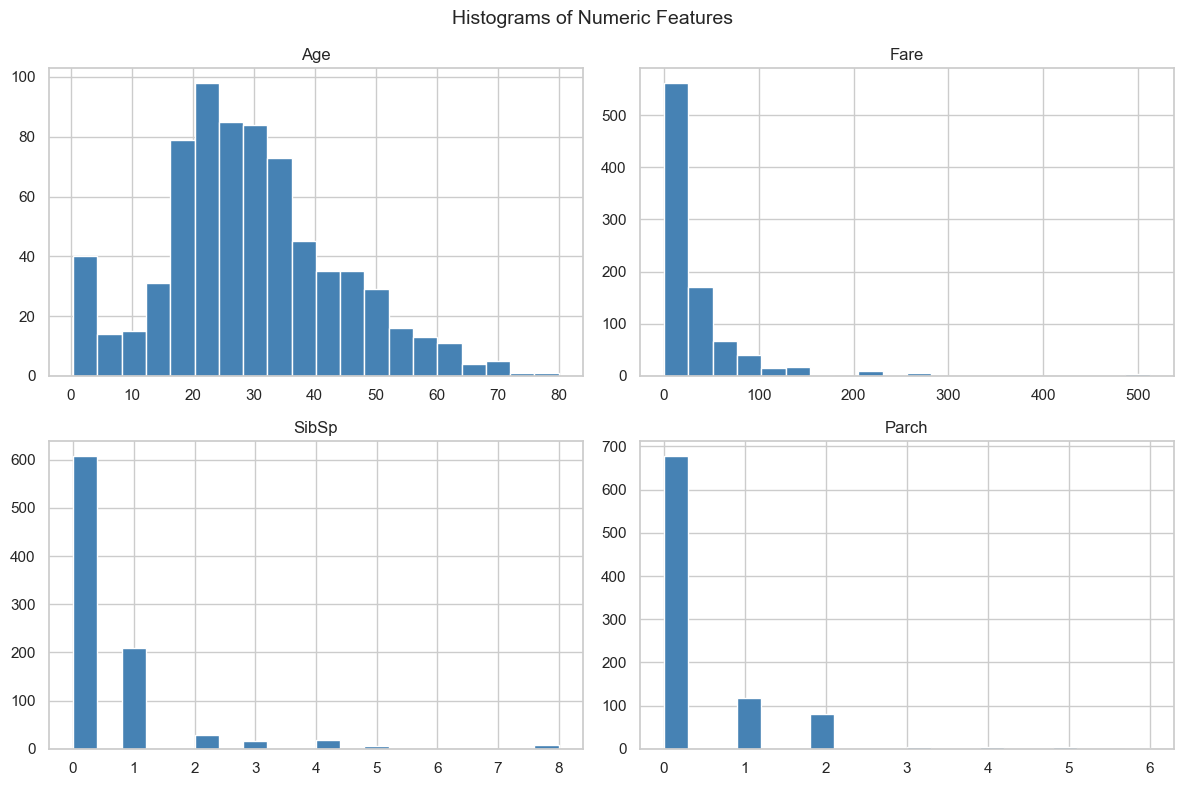

In [8]:
# --- Histograms for all numeric columns ---
df[['Age', 'Fare', 'SibSp', 'Parch']].hist(
    bins=20, figsize=(12, 8), color='steelblue', edgecolor='white'
)
plt.suptitle('Histograms of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1572\996284302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='Set2', ax=axes[0])
C:\Users\user\AppData\Local\Temp\ipykernel_1572\996284302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2', ax=axes[1])


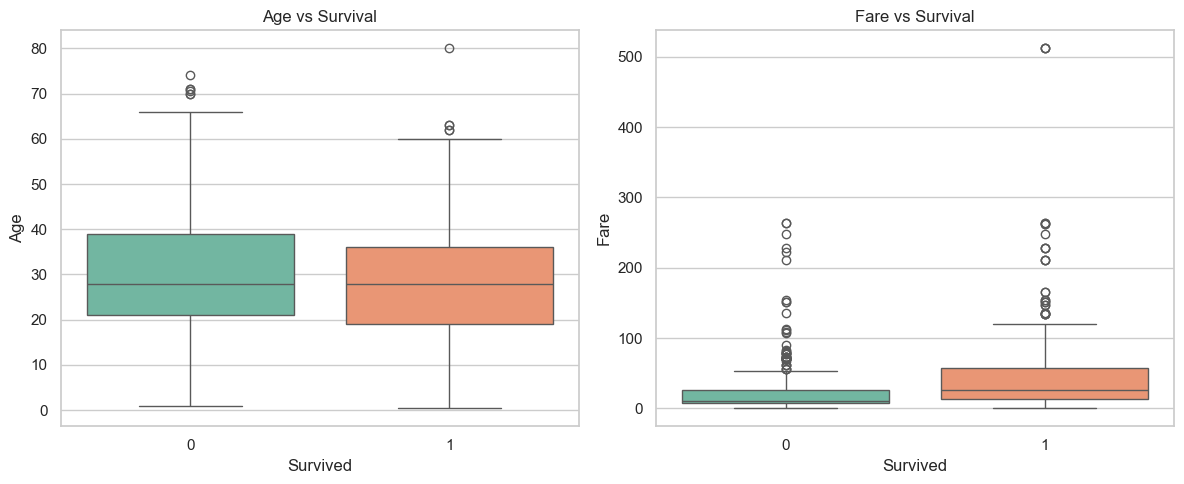

In [9]:
# --- Boxplots to visualize spread and outliers ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Survived', y='Age', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Age vs Survival')

sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Fare vs Survival')

plt.tight_layout()
plt.show()

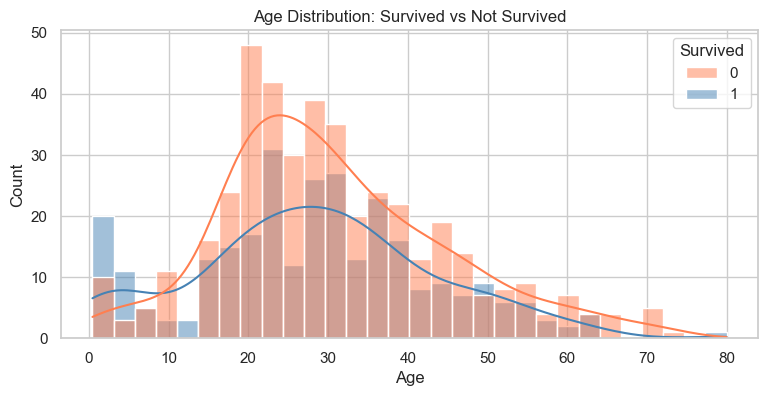

In [18]:

plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30,
             kde=True, palette={0: 'coral', 1: 'steelblue'})
plt.title('Age Distribution: Survived vs Not Survived')
plt.show()

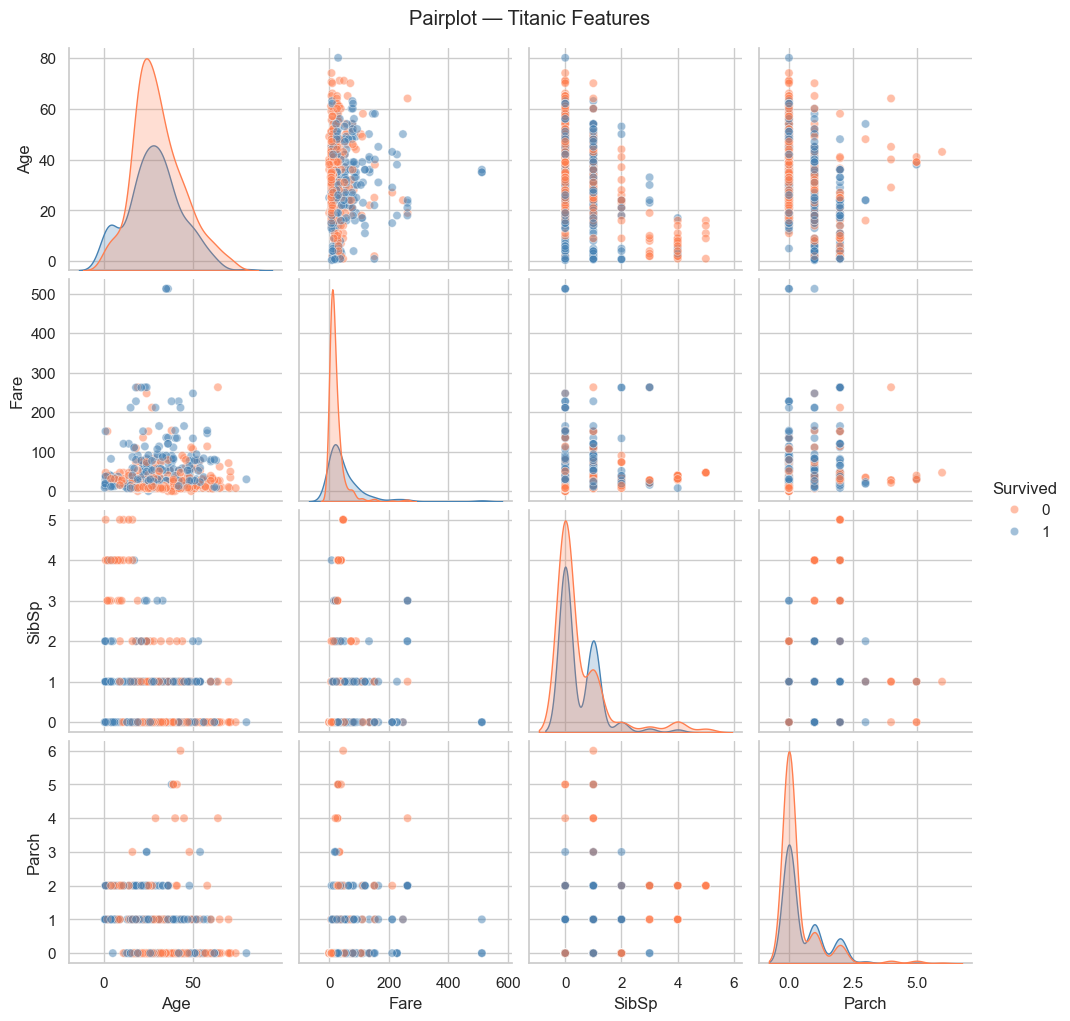

In [19]:
# --- Pairplot (scatter matrix for all numeric features) ---
sns.pairplot(
    df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']].dropna(),
    hue='Survived',
    palette={0: 'coral', 1: 'steelblue'},
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot — Titanic Features', y=1.02)
plt.show()

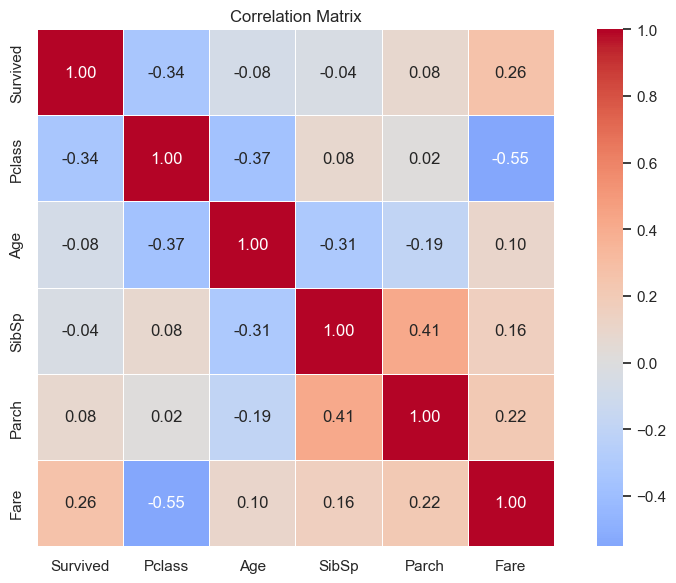

In [20]:
# --- Correlation Heatmap ---
plt.figure(figsize=(9, 6))

corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

sns.heatmap(
    corr,
    annot=True,          # show correlation values
    fmt='.2f',
    cmap='coolwarm',     # red = positive, blue = negative
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1572\1454952057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues_d')


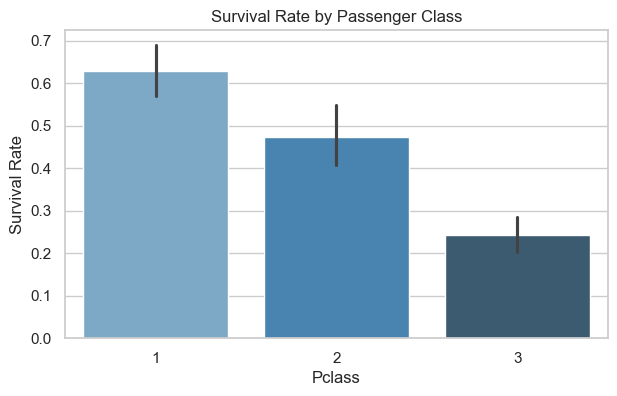

In [21]:
# --- Survival rate by Passenger Class ---
plt.figure(figsize=(7, 4))
sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues_d')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1572\1356171163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set1')


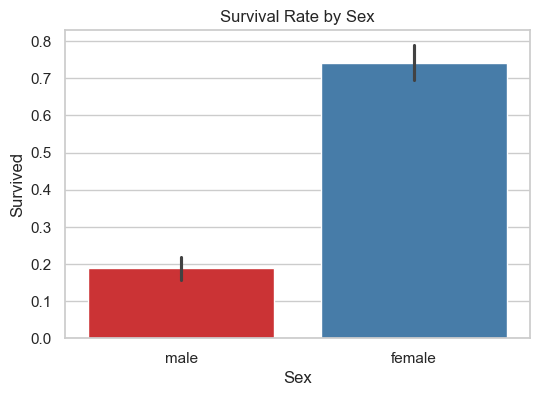

In [22]:
# --- Survival rate by Sex ---
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set1')
plt.title('Survival Rate by Sex')
plt.show()

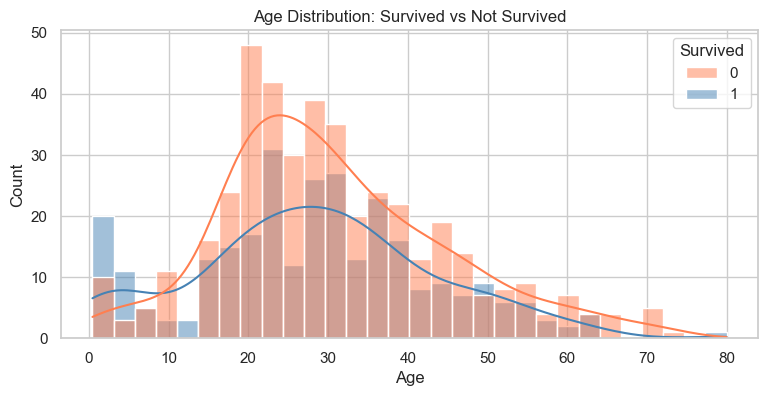

In [23]:
# --- Age distribution split by Survival ---
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30,
             kde=True, palette={0: 'coral', 1: 'steelblue'})
plt.title('Age Distribution: Survived vs Not Survived')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1572\4036655869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Embarked', y='Fare', data=df, palette='Set3')


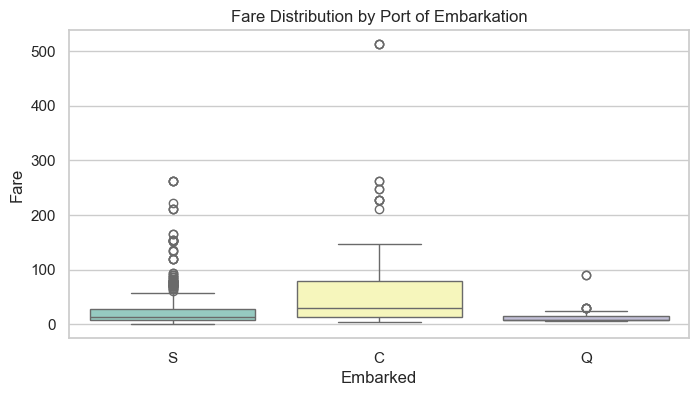

In [24]:
# --- Fare distribution by Embarkation port ---
plt.figure(figsize=(8, 4))
sns.boxplot(x='Embarked', y='Fare', data=df, palette='Set3')
plt.title('Fare Distribution by Port of Embarkation')
plt.show()

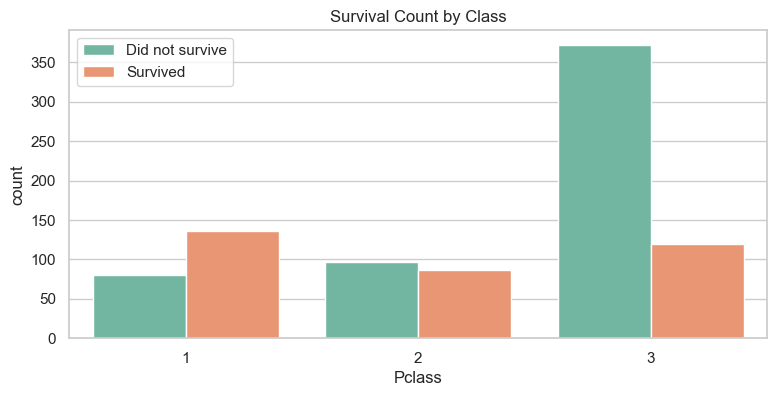

In [25]:
# --- Count of survivors by class and sex (grouped) ---
plt.figure(figsize=(9, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Survival Count by Class')
plt.legend(['Did not survive', 'Survived'])
plt.show()

In [26]:
# Cross-tabulation: Survival count by Sex and Class
print(pd.crosstab(df['Sex'], df['Survived'], margins=True))
print()
print(pd.crosstab(df['Pclass'], df['Survived'], margins=True))

# Survival rate by age group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print("\nSurvival rate by age group:")
print(df.groupby('AgeGroup')['Survived'].mean().round(2))

Survived    0    1  All
Sex                    
female     81  233  314
male      468  109  577
All       549  342  891

Survived    0    1  All
Pclass                 
1          80  136  216
2          97   87  184
3         372  119  491
All       549  342  891

Survival rate by age group:
AgeGroup
Child         0.58
Teen          0.43
YoungAdult    0.38
Adult         0.40
Senior        0.23
Name: Survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_1572\2330438228.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Survived'].mean().round(2))
